In [26]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

In [27]:
path_senal = 'C:\\Users\\cunat\\Desktop\\GIT\\UCV-Churn\\data\\raw\\calidad_senal_zona_mensual.csv'
path_churn = 'C:\\Users\\cunat\\Desktop\\GIT\\UCV-Churn\\data\\raw\\churn_target.csv'

senal = pd.read_csv(path_senal)
churn = pd.read_csv(path_churn)

print('señal:', senal.shape)
print('churn_target:', churn.shape)

display(senal.head(100))
display(churn.head())

señal: (1096, 12)
churn_target: (321987, 3)


,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
0,2023-01-01,Z01,Centro,rural,16625,82.46,4.03,56.17,30.61,3.01,18.51,0
1,2023-02-01,Z01,Centro,rural,16625,82.11,4.31,55.69,30.95,3.06,19.61,0
2,2023-03-01,Z01,Centro,rural,16625,82.19,4.56,55.45,31.05,2.96,16.99,0
3,2023-04-01,Z01,Centro,rural,16625,81.90,4.69,55.72,30.43,3.00,20.81,0
4,2023-05-01,Z01,Centro,rural,16625,81.86,5.38,55.38,30.47,3.01,18.61,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2024-12-01,Z03,Sur,rural,16530,82.35,15.84,NaN,38.71,2.77,23.86,0
96,2025-01-01,Z03,Sur,rural,16530,82.23,16.20,51.31,39.64,2.69,20.74,0
97,2025-02-01,Z03,Sur,rural,16530,82.30,17.11,50.93,39.08,2.73,25.49,0
98,2025-03-01,Z03,Sur,rural,16530,82.64,17.96,51.11,39.67,2.76,26.55,0


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


# DATA CLEANING

In [28]:
senal.info()

<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha                  1096 non-null   str    
 1   zona_id                1096 non-null   str    
 2   region                 1096 non-null   str    
 3   tipo_zona              1096 non-null   str    
 4   poblacion_zona         1096 non-null   int64  
 5   cobertura_4g_pct       1064 non-null   float64
 6   cobertura_5g_pct       1064 non-null   float64
 7   latencia_ms            1063 non-null   float64
 8   velocidad_media_mbps   1096 non-null   float64
 9   tasa_cortes_pct        1096 non-null   float64
 10  indice_calidad_global  1096 non-null   float64
 11  incidencia_masiva      1096 non-null   int64  
dtypes: float64(6), int64(2), str(4)
memory usage: 130.9 KB


In [29]:
# Variables categóricas
senal_cat_cols = [
    'zona_id',
    'region',
    'tipo_zona',
    'incidencia_masiva'
]

# Variables numéricas
senal_num_cols = [
    'poblacion_zona',
    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'latencia_ms',
    'velocidad_media_mbps',
    'tasa_cortes_pct',
    'indice_calidad_global'
]

# Variable temporal
senal_date_cols = [
    'fecha'
]

In [30]:
print('Categóricas:', senal_cat_cols)
print('Numéricas:', senal_num_cols)
print('Temporales:', senal_date_cols)

Categóricas: ['zona_id', 'region', 'tipo_zona', 'incidencia_masiva']
Numéricas: ['poblacion_zona', 'cobertura_4g_pct', 'cobertura_5g_pct', 'latencia_ms', 'velocidad_media_mbps', 'tasa_cortes_pct', 'indice_calidad_global']
Temporales: ['fecha']


In [31]:
senal_clean = senal.copy()

In [32]:
senal_clean.duplicated(
    subset=['zona_id', 'fecha', 'tipo_zona']
).sum()

np.int64(16)

In [33]:
duplicados = senal_clean[
    senal_clean.duplicated(keep=False)
]

duplicados.sort_values(
    ['zona_id', 'fecha']
)

,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
217,2023-02-01,Z07,Centro,rural,15473,81.16,5.41,54.14,32.91,3.05,17.51,0
1084,2023-02-01,Z07,Centro,rural,15473,81.16,5.41,54.14,32.91,3.05,17.51,0
313,2025-02-01,Z09,Norte,urbana_premium,102625,93.59,54.44,27.40,88.09,1.05,55.06,0
1088,2025-02-01,Z09,Norte,urbana_premium,102625,93.59,54.44,27.40,88.09,1.05,55.06,0
331,2023-08-01,Z10,Este,suburbana,27514,89.94,15.41,40.49,55.61,1.96,34.78,0
1087,2023-08-01,Z10,Este,suburbana,27514,89.94,15.41,40.49,55.61,1.96,34.78,0
340,2024-05-01,Z10,Este,suburbana,27514,90.06,24.98,38.80,58.85,1.98,35.84,0
1080,2024-05-01,Z10,Este,suburbana,27514,90.06,24.98,38.80,58.85,1.98,35.84,0
395,2025-12-01,Z11,Oeste,suburbana,41163,89.77,46.33,34.80,72.92,1.52,48.18,0
1092,2025-12-01,Z11,Oeste,suburbana,41163,89.77,46.33,34.80,72.92,1.52,48.18,0


In [34]:
senal_clean = senal_clean.drop_duplicates()

In [40]:
senal_clean[
    senal_clean.isnull().any(axis=1)
]

,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
32,2025-09-01,Z01,Centro,rural,16625,81.93,23.79,NaN,48.93,2.37,28.81,0
37,2023-02-01,Z02,Oeste,suburbana,46400,89.74,10.63,NaN,55.32,1.48,33.52,0
62,2025-03-01,Z02,Oeste,suburbana,46400,90.18,36.17,NaN,69.55,1.38,43.74,0
80,2023-09-01,Z03,Sur,rural,16530,81.99,NaN,55.31,31.59,3.36,18.62,0
83,2023-12-01,Z03,Sur,rural,16530,81.50,8.60,NaN,32.74,3.31,20.39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1002,2025-07-01,Z28,Sur,urbana_premium,64486,94.13,NaN,24.98,93.54,0.66,60.86,0
1014,2023-07-01,Z29,Oeste,urbana_premium,67334,94.06,NaN,32.60,76.04,1.29,42.80,0
1034,2025-03-01,Z29,Oeste,urbana_premium,67334,NaN,56.07,267.30,92.38,0.76,56.17,0
1044,2023-01-01,Z30,Centro,suburbana,33966,90.15,9.51,NaN,52.54,1.37,30.27,0


In [41]:
senal_clean['cobertura_4g_pct'] = (
    senal_clean
    .groupby('tipo_zona')['cobertura_4g_pct']
    .transform(lambda x: x.fillna(x.median()))
)

In [42]:
senal_clean['cobertura_5g_pct'] = (
    senal_clean
    .groupby('tipo_zona')['cobertura_5g_pct']
    .transform(lambda x: x.fillna(x.median()))
)

In [43]:
senal_clean['latencia_ms'] = (
    senal_clean
    .groupby('tipo_zona')['latencia_ms']
    .transform(lambda x: x.fillna(x.median()))
)

In [44]:
senal_clean.isnull().sum()

fecha                    0
zona_id                  0
region                   0
tipo_zona                0
poblacion_zona           0
cobertura_4g_pct         0
cobertura_5g_pct         0
latencia_ms              0
velocidad_media_mbps     0
tasa_cortes_pct          0
indice_calidad_global    0
incidencia_masiva        0
dtype: int64

In [47]:
senal_clean[
    senal_clean['velocidad_media_mbps'] < 0
].count()

fecha                    16
zona_id                  16
region                   16
tipo_zona                16
poblacion_zona           16
cobertura_4g_pct         16
cobertura_5g_pct         16
latencia_ms              16
velocidad_media_mbps     16
tasa_cortes_pct          16
indice_calidad_global    16
incidencia_masiva        16
dtype: int64

In [48]:
senal_clean = senal_clean[
    senal_clean['velocidad_media_mbps'] >= 0
]

In [49]:
senal_clean[
    senal_clean['velocidad_media_mbps'] < 0
].count()

fecha                    0
zona_id                  0
region                   0
tipo_zona                0
poblacion_zona           0
cobertura_4g_pct         0
cobertura_5g_pct         0
latencia_ms              0
velocidad_media_mbps     0
tasa_cortes_pct          0
indice_calidad_global    0
incidencia_masiva        0
dtype: int64

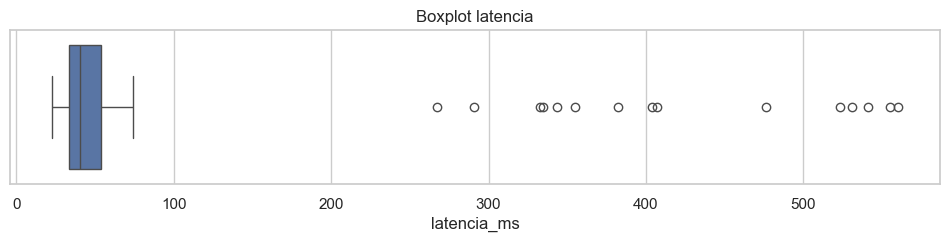

In [50]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=senal_clean['latencia_ms']
)

plt.title('Boxplot latencia')

plt.show()

In [58]:
senal_clean[
    (senal_clean['latencia_ms'] >= 200) &
    (senal_clean['latencia_ms'] <= 600)
]

,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
93,2024-10-01,Z03,Sur,rural,16530,81.99,14.60,541.10,37.27,3.05,22.86,0
126,2024-07-01,Z04,Centro,suburbana,55457,90.32,27.27,382.00,64.03,1.69,39.67,0
364,2023-05-01,Z11,Oeste,suburbana,41163,90.19,13.20,404.10,56.28,1.91,34.81,0
367,2023-08-01,Z11,Oeste,suburbana,41163,90.21,15.84,406.80,55.66,2.05,36.20,0
386,2025-03-01,Z11,Oeste,suburbana,41163,90.27,36.10,354.90,68.07,1.23,42.51,0
394,2025-11-01,Z11,Oeste,suburbana,41163,89.54,44.99,343.80,71.99,1.47,47.61,0
494,2025-03-01,Z14,Norte,rural,13074,82.04,18.36,530.80,39.48,2.93,25.60,0
533,2025-06-01,Z15,Oeste,suburbana,62939,89.27,39.02,334.90,69.81,1.14,43.69,0
648,2023-01-01,Z19,Este,rural,12655,81.39,3.91,555.10,26.44,2.89,13.94,0
672,2025-01-01,Z19,Este,rural,12655,82.28,17.36,523.00,40.57,2.76,27.46,0


In [51]:
for col in [
    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'tasa_cortes_pct'
]:
    
    print(col)
    
    print(
        senal_clean[
            (senal_clean[col] < 0) |
            (senal_clean[col] > 100)
        ].shape
    )

cobertura_4g_pct
(0, 12)
cobertura_5g_pct
(0, 12)
tasa_cortes_pct
(0, 12)


In [52]:
senal_clean['tipo_zona'].value_counts()

tipo_zona
rural             418
suburbana         385
urbana_premium    245
suburbanx           8
rural-1             5
urbana??            3
Name: count, dtype: int64

In [53]:
senal_clean['region'].value_counts()

region
Oeste     249
Sur       213
Este      213
Centro    212
Norte     177
Name: count, dtype: int64

Convertimos fecha a formato date-time ya que ahora mismo está en formato string. El tipo de formato está desordenado, por lo tanto habrá que decirle a Pandas que lo ordene por día primero y formato mixto.

In [35]:
senal['fecha'] = pd.to_datetime(
    senal['fecha'],
    format='mixed',
    dayfirst=True
)

In [36]:
senal['fecha'].head()

0   2023-01-01
1   2023-01-02
2   2023-01-03
3   2023-01-04
4   2023-01-05
Name: fecha, dtype: datetime64[us]

In [37]:
senal.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha,1096,2024-01-09 15:14:27.153284,2023-01-01 00:00:00,2023-01-10 00:00:00,2024-01-07 00:00:00,2025-01-03 00:00:00,2025-12-01 00:00:00,NaN
poblacion_zona,"1,096.00","41,875.18","11,707.00","16,625.00","39,248.00","56,619.00","107,159.00","27,567.00"
cobertura_4g_pct,"1,064.00",87.76,79.23,82.09,89.86,90.50,95.39,4.94
cobertura_5g_pct,"1,064.00",25.23,2.77,12.92,21.25,35.38,71.13,15.87
latencia_ms,"1,063.00",47.64,22.90,33.47,40.39,53.70,559.90,47.31
velocidad_media_mbps,"1,096.00",55.07,-86.88,36.31,56.12,72.21,97.34,23.90
tasa_cortes_pct,"1,096.00",2.06,0.42,1.22,1.90,2.95,8.40,1.04
indice_calidad_global,"1,096.00",35.10,13.94,23.79,34.78,44.06,65.48,12.24
incidencia_masiva,"1,096.00",0.00,0.00,0.00,0.00,0.00,1.00,0.07


In [54]:
senal_clean.groupby('zona_id')['fecha'].count()

zona_id
Z01    35
Z02    36
Z03    36
Z04    35
Z05    36
Z06    35
Z07    35
Z08    36
Z09    36
Z10    35
Z11    36
Z12    36
Z13    36
Z14    34
Z15    35
Z16    36
Z17    35
Z18    35
Z19    36
Z20    36
Z21    35
Z22    34
Z23    35
Z24    36
Z25    35
Z26    35
Z27    36
Z28    36
Z29    36
Z30    36
Name: fecha, dtype: int64

In [55]:
senal_clean['incidencia_masiva'].value_counts()

incidencia_masiva
0    1060
1       4
Name: count, dtype: int64

In [57]:
senal_clean[
    senal_clean['incidencia_masiva'] == 1
]

,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
305,2024-06-01,Z09,Norte,urbana_premium,102625,90.43,40.33,46.90,62.48,4.49,42.22,1
413,2024-06-01,Z12,Norte,rural,11707,79.64,11.88,71.11,11.37,7.77,17.62,1
809,2024-06-01,Z23,Norte,rural,20553,79.27,12.74,69.83,16.49,7.49,17.49,1
953,2024-06-01,Z27,Norte,suburbana,42704,87.66,23.97,61.98,50.18,6.54,29.98,1


In [71]:
# =========================
# Detección de valores raros
# =========================

# 1. Cobertura 4G fuera de rango [0,100]

cobertura_4g_invalidos = senal_clean[
    (senal_clean['cobertura_4g_pct'] < 0) |
    (senal_clean['cobertura_4g_pct'] > 100)
]

print('Cobertura 4G inválidos:')
display(cobertura_4g_invalidos)


# 2. Cobertura 5G fuera de rango [0,100]

cobertura_5g_invalidos = senal_clean[
    (senal_clean['cobertura_5g_pct'] < 0) |
    (senal_clean['cobertura_5g_pct'] > 100)
]

print('Cobertura 5G inválidos:')
display(cobertura_5g_invalidos)


# 3. Velocidad negativa

velocidad_negativa = senal_clean[
    senal_clean['velocidad_media_mbps'] < 0
]

print('Velocidades negativas:')
display(velocidad_negativa)


# 4. Tasa de cortes negativa

cortes_negativos = senal_clean[
    senal_clean['tasa_cortes_pct'] < 0
]

print('Tasa de cortes negativa:')
display(cortes_negativos)


# 5. Índice calidad global fuera de rango [0,100]

calidad_invalida = senal_clean[
    (senal_clean['indice_calidad_global'] < 0) |
    (senal_clean['indice_calidad_global'] > 100)
]

print('Índice calidad global inválido:')
display(calidad_invalida)

Cobertura 4G inválidos:


,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva


Cobertura 5G inválidos:


,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva


Velocidades negativas:


,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva


Tasa de cortes negativa:


,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva


Índice calidad global inválido:


,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva


# latencia_ms vs indice_calidad_global

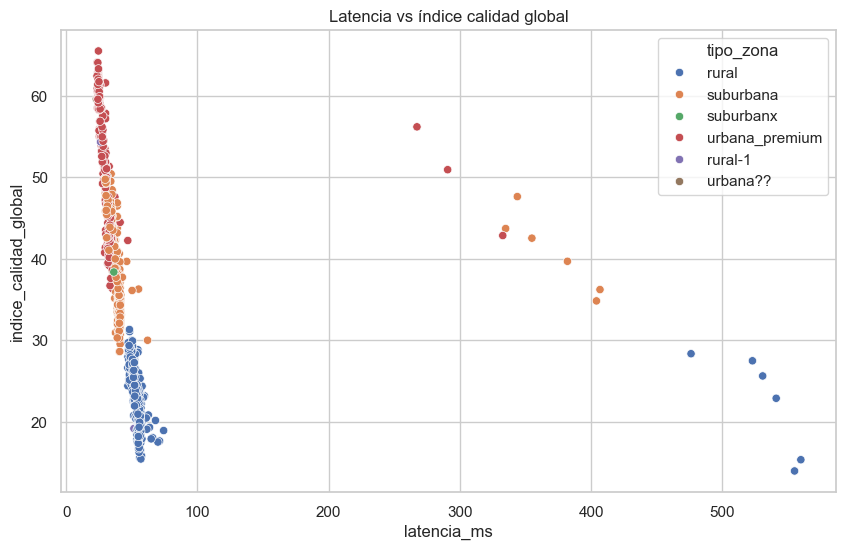

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=senal_clean,
    x='latencia_ms',
    y='indice_calidad_global',
    hue='tipo_zona'
)

plt.title('Latencia vs índice calidad global')

plt.show()

In [60]:
senal_clean[
    ['latencia_ms', 'indice_calidad_global']
].corr()

,latencia_ms,indice_calidad_global
latencia_ms,1.00,-0.24
indice_calidad_global,-0.24,1.00


- Existe una relación negativa entre la latencia y el índice de calidad global, con una correlación de `-0.24`.

- En general, cuando la latencia aumenta, la calidad del servicio tiende a empeorar.

- Esto también se observa en el gráfico, donde las observaciones con latencias más elevadas suelen presentar índices de calidad más bajos.

- Las zonas rurales parecen concentrar gran parte de las latencias extremas y los peores niveles de calidad.

- La correlación no es especialmente fuerte, lo que indica que la calidad global no depende únicamente de la latencia.

- Otros factores como la cobertura 4G/5G, la velocidad media o la estabilidad del servicio también parecen influir en la calidad percibida por el cliente.

# latencia_ms vs velocidad_media_mbps

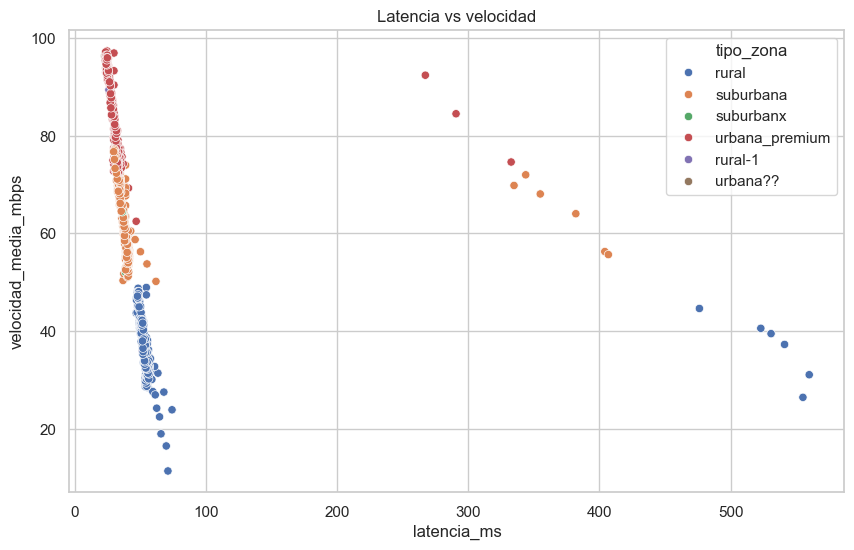

In [62]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=senal_clean,
    x='latencia_ms',
    y='velocidad_media_mbps',
    hue='tipo_zona'
)

plt.title('Latencia vs velocidad')

plt.show()

In [66]:
senal_clean[
    ['latencia_ms', 'velocidad_media_mbps']
].corr()

,latencia_ms,velocidad_media_mbps
latencia_ms,1.00,-0.24
velocidad_media_mbps,-0.24,1.00


- Existe una relación negativa entre la latencia y la velocidad media, con una correlación de `-0.24`.

- En general, cuando la latencia aumenta, la velocidad media de la red tiende a disminuir.

- El gráfico muestra bastante separación por tipo de zona, especialmente entre zonas rurales y urbanas premium.

- Las zonas rurales concentran la mayoría de los casos con latencias más altas y velocidades más bajas.

- Por el contrario, las zonas urbanas premium mantienen menores niveles de latencia y velocidades considerablemente más altas.

- Aunque la relación no es muy fuerte, sí se aprecia una tendencia general donde una peor latencia suele venir acompañada de un peor rendimiento de red.

- Esto sugiere que la experiencia del usuario no depende únicamente de una sola métrica, sino de la combinación de varios factores de calidad de servicio.

# latencia_ms vs tasa_cortes_pct

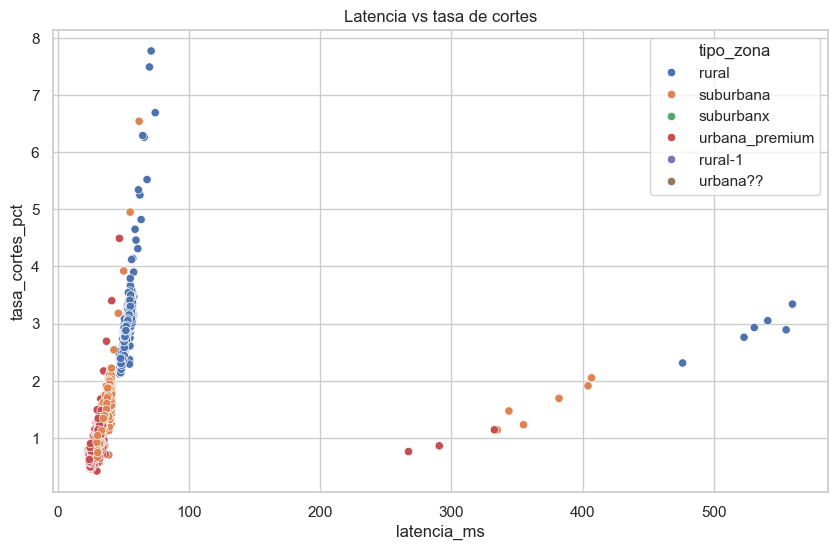

In [63]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=senal_clean,
    x='latencia_ms',
    y='tasa_cortes_pct',
    hue='tipo_zona'
)

plt.title('Latencia vs tasa de cortes')

plt.show()

In [67]:
senal_clean[
    ['latencia_ms', 'tasa_cortes_pct']
].corr()

,latencia_ms,tasa_cortes_pct
latencia_ms,1.00,0.23
tasa_cortes_pct,0.23,1.00


- Existe una relación positiva entre la latencia y la tasa de cortes, con una correlación de `0.23`.

- En general, cuando la latencia aumenta, la tasa de cortes también tiende a incrementarse.

- Aunque la correlación no es especialmente fuerte, el gráfico muestra una tendencia ascendente bastante visible.

- Las zonas rurales concentran gran parte de los casos con mayores niveles de latencia y tasas de cortes más elevadas.

- Las zonas urbanas premium presentan menores tasas de cortes incluso cuando la latencia aumenta moderadamente.

- Esto sugiere que una mayor latencia puede estar asociada a problemas de estabilidad o congestión en la red.

- La dispersión observada indica que la tasa de cortes no depende únicamente de la latencia, sino también de otros factores relacionados con la infraestructura y la calidad de servicio.

# latencia_ms por tipo_zona

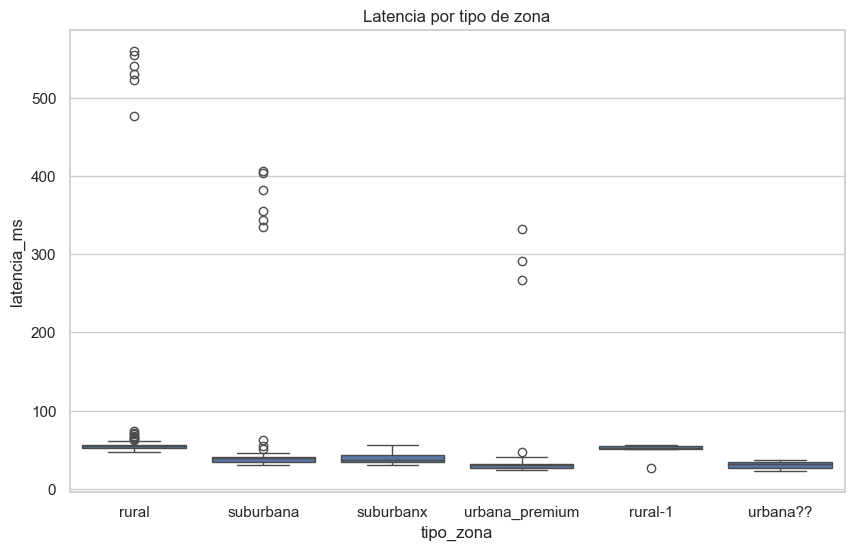

In [64]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=senal_clean,
    x='tipo_zona',
    y='latencia_ms'
)

plt.title('Latencia por tipo de zona')

plt.show()

- Las zonas rurales presentan, en general, los niveles de latencia más elevados del dataset.

- También son las que concentran la mayor cantidad de valores extremos, con varios casos por encima de `500 ms`.

- Las zonas suburbanas muestran una latencia intermedia, aunque también aparecen algunos outliers importantes cercanos a `400 ms`.

- Las zonas urbanas premium mantienen las latencias más bajas y estables, con una menor dispersión en comparación con el resto.

- Esto sugiere que la infraestructura de red en zonas urbanas premium ofrece una experiencia más consistente y eficiente.

- La diferencia entre tipos de zona parece bastante marcada, especialmente entre entornos rurales y urbanos premium.

- Los valores extremos observados podrían estar relacionados con incidencias puntuales o limitaciones de infraestructura en determinadas zonas.

# latencia_ms por region

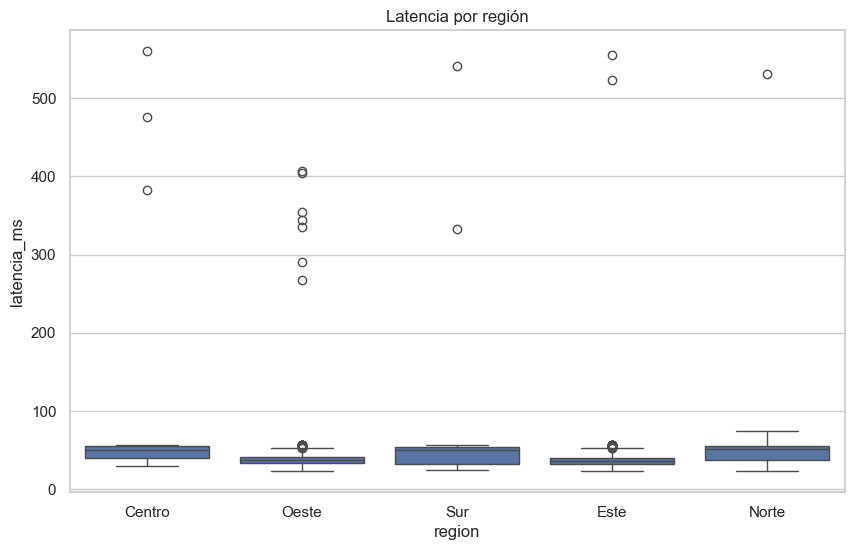

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=senal_clean,
    x='region',
    y='latencia_ms'
)

plt.title('Latencia por región')

plt.show()

- La latencia presenta diferencias moderadas entre regiones, aunque no tan marcadas como las observadas entre tipos de zona.

- Las regiones Centro y Norte parecen mostrar medianas de latencia ligeramente superiores al resto.

- La región Oeste presenta una distribución más estable y concentrada, con menores niveles de dispersión.

- En todas las regiones aparecen valores extremos de latencia, algunos superiores a `500 ms`.

- Estos outliers sugieren la existencia de incidencias puntuales o episodios de degradación severa de red.

- La región Centro concentra algunos de los casos más extremos del dataset.

- A pesar de las diferencias regionales, la mayor variabilidad parece estar más relacionada con el tipo de zona (rural, suburbana, urbana) que con la región geográfica en sí.

# Conclusion:

- La latencia parece ser una variable potencialmente importante para explicar churn, ya que los incrementos de latencia suelen venir acompañados de una peor calidad global del servicio.

- Las zonas con mayores niveles de latencia también presentan, en muchos casos, menores velocidades medias y mayores tasas de cortes, lo que podría traducirse en una peor experiencia para el cliente.

- Las zonas rurales concentran gran parte de los peores indicadores de red:
  - mayor latencia,
  - más cortes,
  - menor calidad global,
  - y menor velocidad media.

  Esto podría convertirlas en zonas con mayor riesgo potencial de abandono.

- Las zonas urbanas premium muestran un comportamiento mucho más estable y mejores métricas de calidad, lo que sugiere una experiencia de usuario más satisfactoria y, potencialmente, menor propensión al churn.

- Aunque las correlaciones observadas no son extremadamente fuertes, sí muestran patrones consistentes que indican que la degradación técnica del servicio puede influir negativamente en la satisfacción del cliente.

- La calidad de experiencia parece depender de la combinación de múltiples factores de red y no únicamente de una sola métrica aislada.

- Los valores extremos de latencia podrían representar incidencias severas o problemas de infraestructura que afecten directamente a la percepción del servicio por parte del cliente.

- Este EDA sugiere que variables relacionadas con calidad de señal y estabilidad de red podrían aportar valor predictivo en futuros modelos de churn.